#  Practical Code Challenges – Image Filtering Lab



##  Challenge 1: Kernel Size Experiment

1. Apply the uniform (box) filter using different kernel sizes:

   - 3×3

   - 5×5

   - 9×9

2. Display the results side by side.

3. Describe how increasing kernel size affects:

   - Blur strength

   - Image details

   - Sharp edges



---



##  Challenge 2: Gaussian Sigma Investigation

1. Apply Gaussian blur with:

   - Small sigma (e.g., 1)

   - Medium sigma (e.g., 5)

   - Large sigma (e.g., 15)

2. Keep kernel size constant.

3. Observe and explain:

   - What role does sigma play?

   - How is Gaussian blur different from uniform blur visually?



---



##  Challenge 3: Manual Convolution

1. Create your own custom 3×3 kernel using NumPy.

2. Apply it using `cv2.filter2D()`.

3. Try:

   - A sharpening kernel

   - An edge detection kernel

4. Compare results with built-in filters.



---



##  Challenge 4: Noise Removal Test

1. Add artificial noise to the original image:

   - Gaussian noise

   - Salt-and-pepper noise

2. Apply:

   - Uniform filter

   - Gaussian filter

3. Which filter performs better for each noise type?

4. Justify your answer with visual comparison.



---



##  Challenge 5: Edge Preservation Study

1. Blur the image using:

   - Box filter

   - Gaussian filter

2. Compare how edges are affected.

3. Measure pixel intensity differences across edges before and after filtering.

4. Which method preserves structure better?



---



##  Challenge 6: Performance Comparison

1. Measure execution time for:

   - `cv2.filter2D()`

   - `cv2.GaussianBlur()`

2. Run each filter multiple times.

3. Calculate average processing time.

4. Which method is faster? Why?



---



##  Challenge 7: Kernel Normalization Test

1. Create a kernel that is NOT normalized (sum ≠ 1).

2. Apply it to the image.

3. Observe what happens to brightness.

4. Fix the issue by normalizing the kernel.



---



#  Final Challenge: Smart Filter Selector

Create a mini program that:

- Asks the user to choose:

  - Uniform filter

  - Gaussian filter

- Asks for kernel size and sigma (if Gaussian)

- Applies the selected filter

- Displays original and filtered images side by side

Make it structured, reusable, and well-commented.

In [ ]:
!pip install opencv-python

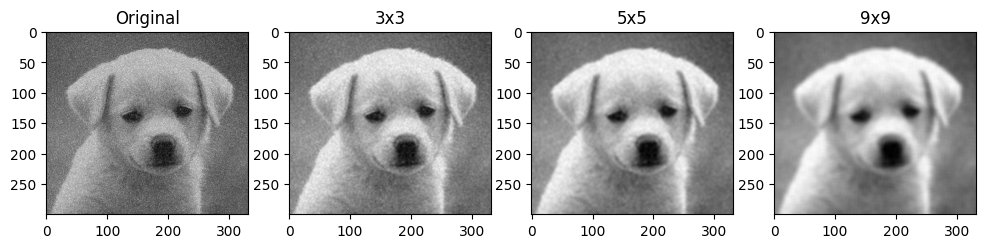

In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread("/Users/macstore.uz/Week_6/phpchZD7j.png", 0)

k3 = cv2.blur(img, (3,3))
k5 = cv2.blur(img, (5,5))
k9 = cv2.blur(img, (9,9))

plt.figure(figsize=(12,4))
plt.subplot(1,4,1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1,4,2), plt.imshow(k3, cmap="gray"), plt.title("3x3")
plt.subplot(1,4,3), plt.imshow(k5, cmap="gray"), plt.title("5x5")
plt.subplot(1,4,4), plt.imshow(k9, cmap="gray"), plt.title("9x9")
plt.show()

TASK 2 – Gaussian Sigma Investigation (SOLUTION)

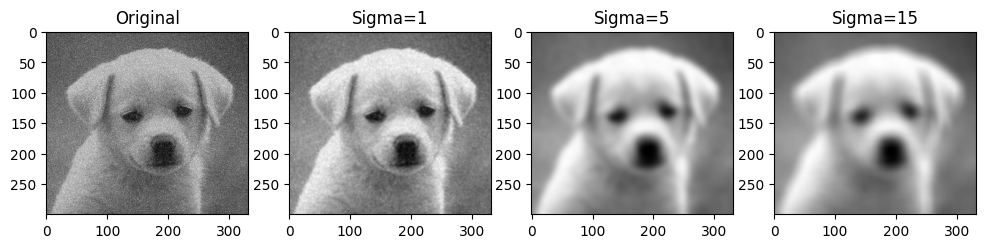

In [3]:
g1 = cv2.GaussianBlur(img, (21,21), 1)
g5 = cv2.GaussianBlur(img, (21,21), 5)
g15 = cv2.GaussianBlur(img, (21,21), 15)

plt.figure(figsize=(12,4))
plt.subplot(1,4,1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1,4,2), plt.imshow(g1, cmap="gray"), plt.title("Sigma=1")
plt.subplot(1,4,3), plt.imshow(g5, cmap="gray"), plt.title("Sigma=5")
plt.subplot(1,4,4), plt.imshow(g15, cmap="gray"), plt.title("Sigma=15")
plt.show()

 TASK 3 – Manual Convolution (SOLUTION)

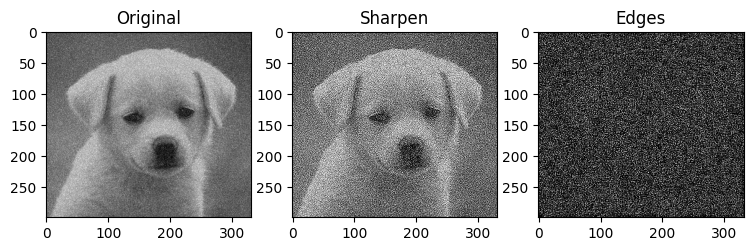

In [4]:
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
edge_kernel = np.array([[-1,-1,-1],[-1,8,-1],[-1,-1,-1]])

sharpened = cv2.filter2D(img, -1, sharpen_kernel)
edges = cv2.filter2D(img, -1, edge_kernel)

plt.figure(figsize=(9,4))
plt.subplot(1,3,1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(sharpened, cmap="gray"), plt.title("Sharpen")
plt.subplot(1,3,3), plt.imshow(edges, cmap="gray"), plt.title("Edges")
plt.show()



In [ ]:
TASK 4 – Noise Removal Test (SOLUTION)

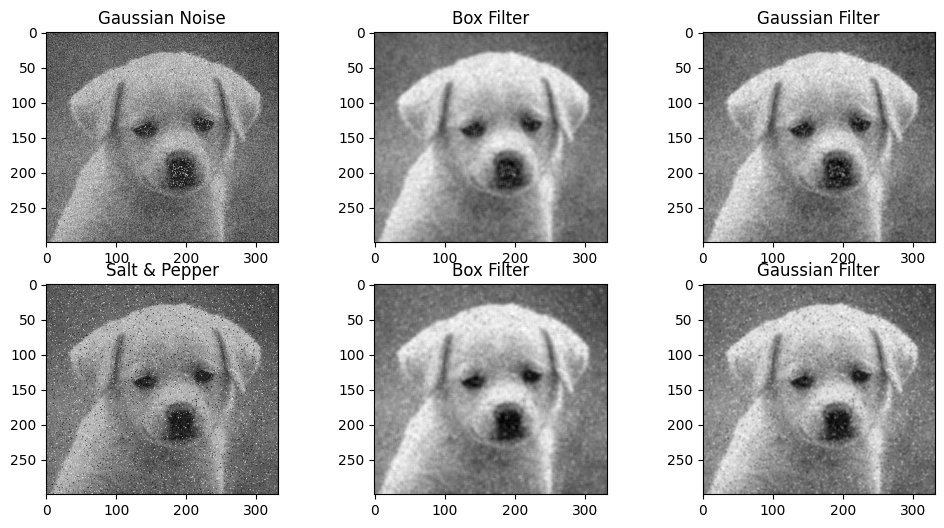

In [9]:
gauss_noise = img + np.random.normal(0,20,img.shape).astype(np.uint8)

sp = img.copy()
prob = 0.02
rnd = np.random.rand(*img.shape)
sp[rnd < prob] = 0
sp[rnd > 1-prob] = 255

box_gauss = cv2.blur(gauss_noise, (5,5))
gauss_gauss = cv2.GaussianBlur(gauss_noise, (5,5), 1)

box_sp = cv2.blur(sp, (5,5))
gauss_sp = cv2.GaussianBlur(sp, (5,5), 1)

plt.figure(figsize=(12,6))
plt.subplot(2,3,1), plt.imshow(gauss_noise, cmap="gray"), plt.title("Gaussian Noise")
plt.subplot(2,3,2), plt.imshow(box_gauss, cmap="gray"), plt.title("Box Filter")
plt.subplot(2,3,3), plt.imshow(gauss_gauss, cmap="gray"), plt.title("Gaussian Filter")

plt.subplot(2,3,4), plt.imshow(sp, cmap="gray"), plt.title("Salt & Pepper")
plt.subplot(2,3,5), plt.imshow(box_sp, cmap="gray"), plt.title("Box Filter")
plt.subplot(2,3,6), plt.imshow(gauss_sp, cmap="gray"), plt.title("Gaussian Filter")
plt.show()


TASK 5 – Edge Preservation Study (SOLUTION)

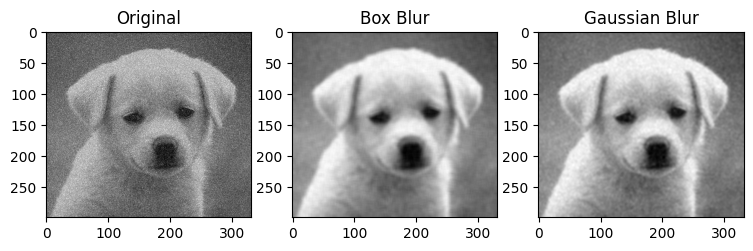

In [10]:
box_blur = cv2.blur(img, (7,7))
gauss_blur = cv2.GaussianBlur(img, (7,7), 1.5)

plt.figure(figsize=(9,4))
plt.subplot(1,3,1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(box_blur, cmap="gray"), plt.title("Box Blur")
plt.subplot(1,3,3), plt.imshow(gauss_blur, cmap="gray"), plt.title("Gaussian Blur")
plt.show()

TASK 6 – Performance Comparison (SOLUTION)

In [11]:
import time

def avg_time(func, runs=20):
    times = []
    for _ in range(runs):
        t0 = time.time()
        func()
        times.append(time.time() - t0)
    return np.mean(times)

t1 = avg_time(lambda: cv2.filter2D(img, -1, sharpen_kernel))
t2 = avg_time(lambda: cv2.GaussianBlur(img, (5,5), 1))

print("filter2D avg time:", t1)
print("GaussianBlur avg time:", t2)

filter2D avg time: 0.0003596067428588867
GaussianBlur avg time: 0.00010313987731933594


TASK 7 – Kernel Normalization Test (SOLUTION)

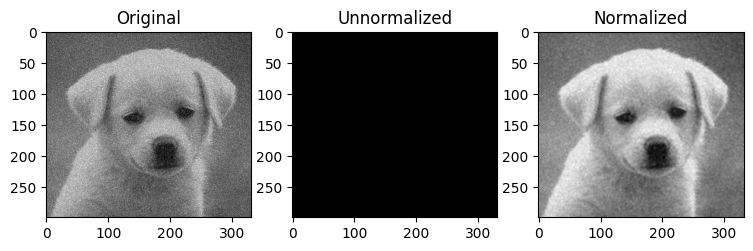

In [12]:
bad_kernel = np.ones((3,3))*5
bad_img = cv2.filter2D(img, -1, bad_kernel)

norm_kernel = bad_kernel / np.sum(bad_kernel)
fixed_img = cv2.filter2D(img, -1, norm_kernel)

plt.figure(figsize=(9,4))
plt.subplot(1,3,1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1,3,2), plt.imshow(bad_img, cmap="gray"), plt.title("Unnormalized")
plt.subplot(1,3,3), plt.imshow(fixed_img, cmap="gray"), plt.title("Normalized")
plt.show()

FINAL TASK – Smart Filter Selector (SOLUTION)

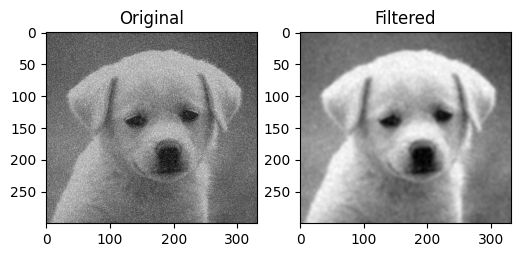

In [13]:
def smart_filter(image, ftype, k, sigma=1):
    if ftype == "uniform":
        return cv2.blur(image, (k,k))
    if ftype == "gaussian":
        return cv2.GaussianBlur(image, (k,k), sigma)

out = smart_filter(img, "gaussian", 7, 2)

plt.figure(figsize=(6,3))
plt.subplot(1,2,1), plt.imshow(img, cmap="gray"), plt.title("Original")
plt.subplot(1,2,2), plt.imshow(out, cmap="gray"), plt.title("Filtered")
plt.show()